# Notebook for the visualization of the performance evaluation subsampling task

In [2]:
import os
import re
import glob
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
basefolder = "../../../CAGEscan/"
info_file = "pipeline_info/execution_trace*.txt"

In [4]:
subsampling_list = [
    "cagescan_cell_line_n2_results",
    "cagescan_cell_line_n5_results",
    "cagescan_cell_line_n10_results",
    "cagescan_cell_line_n14_results",
    "cagescan_cell_line_results",
    "cagescan_primary_n_cell_line_results",
    "all_cagescan_results"
]
subsampling_map = {
    "cagescan_cell_line_n2_results": "2",
    "cagescan_cell_line_n5_results": "5",
    "cagescan_cell_line_n10_results": "10",
    "cagescan_cell_line_n14_results": "14",
    "cagescan_cell_line_results": "22",
    "cagescan_primary_n_cell_line_results": "39",
    "all_cagescan_results": "62"}

In [5]:
def convert_size_to_bytes(size_str):
    size_str = size_str.strip().upper()
    if 'TB' in size_str:
        value = float(size_str.replace('TB', '').strip())
        return value * (1024**4)  # Convert TB to bytes
    elif 'GB' in size_str:
        value = float(size_str.replace('GB', '').strip())
        return value * (1024**3)  # Convert GB to bytes
    elif 'MB' in size_str:
        value = float(size_str.replace('MB', '').strip())
        return value * (1024**2)  # Convert MB to bytes
    elif 'KB' in size_str:
        value = float(size_str.replace('KB', '').strip())
        return value * 1024     # Convert KB to bytes
    else:
        try:
            return float(size_str) # Assume it's already a number in bytes
        except ValueError:
            return None  # Handle cases where the format is unexpected


In [6]:
# Convert function
def to_milliseconds(duration):
    time_units = {
        'd': 24 * 60 * 60 * 1000,
        'h': 60 * 60 * 1000,
        'm': 60 * 1000,
        's': 1000,
        'ms': 1
    }

    # Match ms first, so it doesn't interfere with 'm' (minutes)
    pattern = r'(?:(\d+(?:\.\d+)?)d)?\s*' \
              r'(?:(\d+(?:\.\d+)?)h)?\s*' \
              r'(?:(\d+(?:\.\d+)?)m(?!s))?\s*' \
              r'(?:(\d+(?:\.\d+)?)s)?\s*' \
              r'(?:(\d+(?:\.\d+)?)ms)?'

    match = re.fullmatch(pattern, duration.strip())
    if not match:
        return None

    d, h, m, s, ms = match.groups(default='0')
    total_ms = (
        float(d) * time_units['d'] +
        float(h) * time_units['h'] +
        float(m) * time_units['m'] +
        float(s) * time_units['s'] +
        float(ms) * time_units['ms']
    )
    return int(total_ms)

In [7]:
total_duration = {}
peak_rss = {}

for subsampling in subsampling_list:
    subs_count = subsampling_map[subsampling]
    print(f"Processing {subsampling}...")
    folder = os.path.join(basefolder, subsampling)
    subs_info_file = glob.glob(os.path.join(folder, info_file))[0]
    
    if not os.path.exists(subs_info_file):
        print(f"No info files found for {subs_info_file}.")
        continue
    
    info_df = pd.read_csv(subs_info_file, sep="\t", header=0)
    peak_rss_num = info_df["peak_rss"].apply(convert_size_to_bytes).max()
    peak_rss[subs_count] = peak_rss_num
    milliseconds = info_df["duration"].apply(to_milliseconds)
    total_duration[subs_count] = milliseconds.sum()

Processing cagescan_cell_line_n2_results...
Processing cagescan_cell_line_n5_results...
Processing cagescan_cell_line_n10_results...
Processing cagescan_cell_line_n14_results...
Processing cagescan_cell_line_results...
Processing cagescan_primary_n_cell_line_results...
Processing all_cagescan_results...


In [8]:
total_duration

{'2': np.int64(2035034),
 '5': np.int64(7400813),
 '10': np.int64(20364534),
 '14': np.int64(39510462),
 '22': np.int64(83261978),
 '39': np.int64(168976264),
 '62': np.int64(350766481)}

In [9]:
import math

[1.3862943611198906, 8.047189562170502, 23.02585092994046, 36.94680261461362, 68.00293397388296, 142.8789041990562, 255.88233187279567]


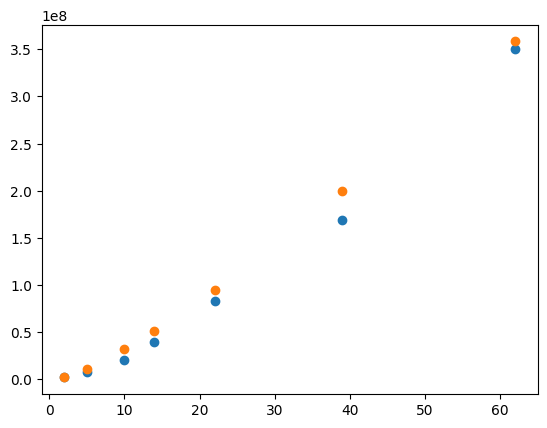

In [18]:
ns = [2, 5, 10, 14, 22, 39, 62]
ts = [2035034, 7400813, 20364534, 39510462, 83261978, 168976264, 350766481]
plt.scatter(ns, ts)
print([n*math.log(n) for n in ns])
plt.scatter(ns, [1.4e6*n*math.log(n) for n in ns])

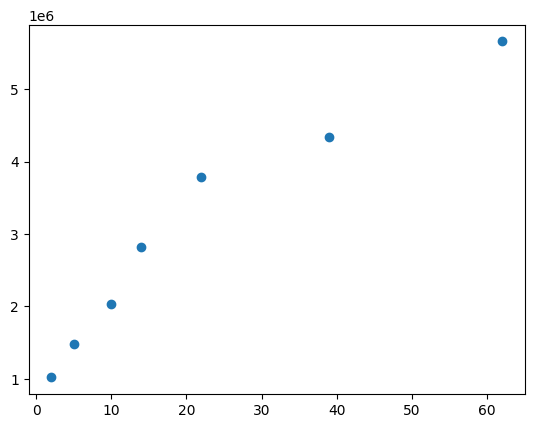

In [58]:
# big O calculation assumin linearity
ns = [2, 5, 10, 14, 22, 39, 62]
ts = [2035034, 7400813, 20364534, 39510462, 83261978, 168976264, 350766481]
ratios = []
for n, t in zip(ns, ts):
    ratios.append(t/(n))
plt.scatter(ns, ratios)

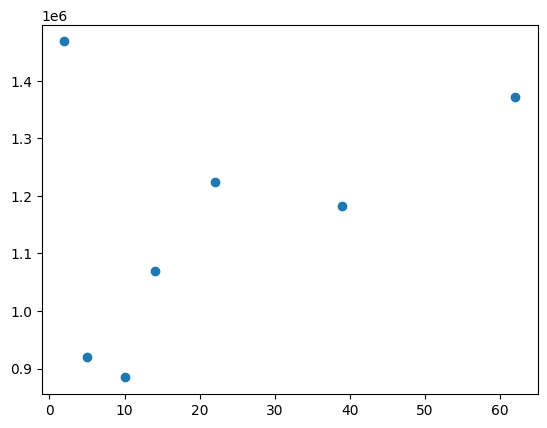

In [59]:
# big O calculation assumin nlogn performance
ns = [2, 5, 10, 14, 22, 39, 62]
ts = [2035034, 7400813, 20364534, 39510462, 83261978, 168976264, 350766481]
ratios = []
for n, t in zip(ns, ts):
    ratios.append(t/(n*math.log(n)))
plt.scatter(ns, ratios)

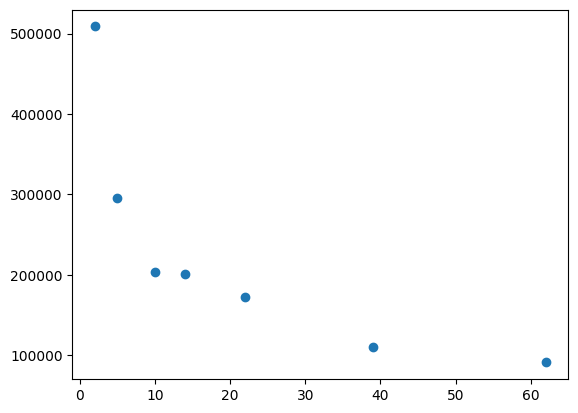

In [60]:
# big O calculation assuming quadratic performance
ns = [2, 5, 10, 14, 22, 39, 62]
ts = [2035034, 7400813, 20364534, 39510462, 83261978, 168976264, 350766481]
ratios = []
for n, t in zip(ns, ts):
    ratios.append(t/(n*n))
plt.scatter(ns, ratios)

Conclusion: it is nlog(n)

In [13]:
# convert to hours
total_duration_hour = {}
for sample, mstime in total_duration.items():
    total_duration_hour[sample] = mstime/(60 * 60 * 1000)
total_duration_hour

{'2': np.float64(0.5652872222222223),
 '5': np.float64(2.0557813888888887),
 '10': np.float64(5.656815),
 '14': np.float64(10.975128333333334),
 '22': np.float64(23.12832722222222),
 '39': np.float64(46.93785111111111),
 '62': np.float64(97.43513361111111)}

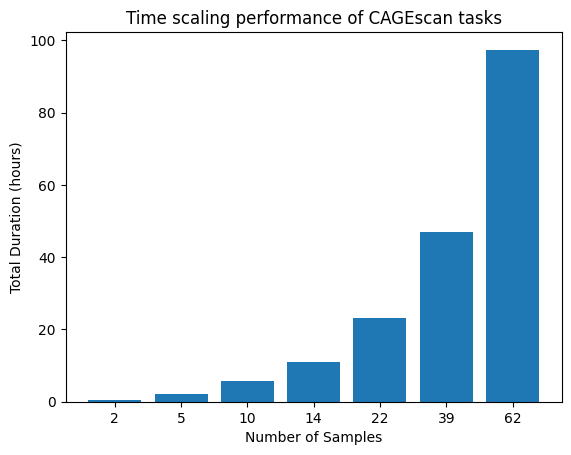

In [15]:
# Extract keys (categories) and values (heights) from the dictionary
categories = list(total_duration_hour.keys())
values = list(total_duration_hour.values())

# Create the bar chart
plt.bar(categories, values)

# Add labels and title for clarity
plt.xlabel('Number of Samples')
plt.ylabel('Total Duration (hours)')
plt.title('Time scaling performance of CAGEscan tasks')

# Display the plot
plt.show()

In [16]:
peak_rss

{'2': 34789235097.6,
 '5': 34789235097.6,
 '10': 34789235097.6,
 '14': 34789235097.6,
 '22': 35218731827.2,
 '39': 70652212019.2,
 '62': 188549064294.4}

In [17]:
# convert to GB
peak_rss_gb = {}
for sample, byterss in peak_rss.items():
    peak_rss_gb[sample] = byterss/(1024**3)
peak_rss_gb

{'2': 32.4,
 '5': 32.4,
 '10': 32.4,
 '14': 32.4,
 '22': 32.8,
 '39': 65.8,
 '62': 175.6}

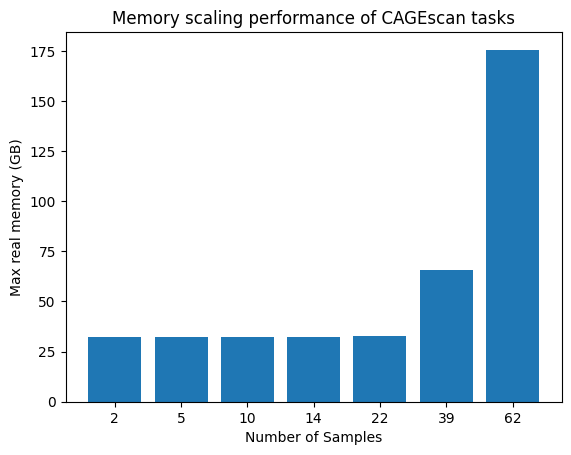

In [18]:
# Extract keys (categories) and values (heights) from the dictionary
categories = list(peak_rss_gb.keys())
values = list(peak_rss_gb.values())

# Create the bar chart
plt.bar(categories, values)

# Add labels and title for clarity
plt.xlabel('Number of Samples')
plt.ylabel('Max real memory (GB)')
plt.title('Memory scaling performance of CAGEscan tasks')

# Display the plot
plt.show()